## Imports

In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
from IPython.display import display, Markdown
import matplotlib.pyplot as plt 
import numpy as np
import scipy as sp
from scipy import stats
import yaml

In [11]:
from caa_model.config import *
from caa_model.models import base_model, disp_classic, sisp_constrained, disp_staggered
from caa_model.models.results import *
from caa_model.models.disp_classic import DISPClassicDDM
from caa_model.models.sisp_constrained import SISPConstrainedDDM
from caa_model.models.disp_staggered import DISPStaggeredDDM

## Setup

In [12]:
data = base_model.DATA

caa_cfg = CAAConfig(
    delta_t=0.025,
    nr_ssteps=8192,
    nr_samples=10000,
    max_t=8.0,
    nr_quantiles=5
)

In [13]:
def display_comparison(evals: list[ModelEvaluation]):
    """Renders a side-by-side comparison Markdown table for multiple ModelEvaluations."""
    methods = " | ".join([f"`{e.method.upper()}`" for e in evals])
    align = " | ".join(["---:"] * len(evals))
    
    trials = " | ".join([f"{e.n_trials:,}" for e in evals])
    params = " | ".join([f"{e.n_params}" for e in evals])
    nll    = " | ".join([f"{e.nll:.2f}" for e in evals])
    aic    = " | ".join([f"**{e.aic:.2f}**" for e in evals])
    bic    = " | ".join([f"**{e.bic:.2f}**" for e in evals])

    md_table = f"""
### Model Evaluation Comparison

| Metric | {methods} |
| :--- | {align} |
| **Trials ($N$)** | {trials} |
| **Parameters ($k$)** | {params} |
| **Negative Log-Likelihood** | {nll} |
| **AIC** | {aic} |
| **BIC** | {bic} |
"""
    display(Markdown(md_table))

## DISP Classic

Previous runs:
params_est = DISPClassicDDM.Params(
    c=0.998,
    mu_r=0.002,
    mu_f=0.306,
    d_r=0.004,
    d_f=0.374,
    tc_bound=0.059,
    r_bound=0.001,
    z0=-0.131,
    mu_r_new=-0.014,
    mu_f_new=-0.244,
    t_post=0.586,
    t0=0.513,
)

Attempt use_qmpe=False
params_est = DISPClassicDDM.Params(
    c=np.float64(0.9839469423322917),
    mu_r=np.float64(-0.05222397104655574),
    mu_f=np.float64(0.334658894406465),
    d_r=np.float64(0.10982475171405692),
    d_f=np.float64(0.2812199313586414),
    tc_bound=np.float64(0.057067129956417106),
    r_bound=np.float64(0.06371382016083388),
    z0=np.float64(-0.11009050559487588),
    mu_r_new=np.float64(-0.20676990609747348),
    mu_f_new=np.float64(-0.08936275590665232),
    t_post=np.float64(0.5646556857397613),
    t0=np.float64(0.4896501191177717),
)

Attempt use_qmpe=True
params_est = DISPClassicDDM.Params(
    c=np.float64(0.951272925024579),
    mu_r=np.float64(0.06354415782567555),
    mu_f=np.float64(0.19444351440361043),
    d_r=np.float64(0.06181859380901922),
    d_f=np.float64(0.27806008703250157),
    tc_bound=np.float64(0.08540477827607344),
    r_bound=np.float64(0.19091029354745948),
    z0=np.float64(-0.12084717045448616),
    mu_r_new=np.float64(-0.07436415519092282),
    mu_f_new=np.float64(-0.20859148075764358),
    t_post=np.float64(0.48425017922081215),
    t0=np.float64(0.4962775458867493),
)

In [14]:
disp_model = DISPClassicDDM(
    config=caa_cfg,
    nr_threads=1,
)

# Optimize over entire data

method = "qmle"
params_est = DISPClassicDDM.Params(
    c=0.998,
    mu_r=0.002,
    mu_f=0.306,
    d_r=0.004,
    d_f=0.374,
    tc_bound=0.059,
    r_bound=0.001,
    z0=-0.131,
    mu_r_new=-0.014,
    mu_f_new=-0.244,
    t_post=0.586,
    t0=0.513,
)

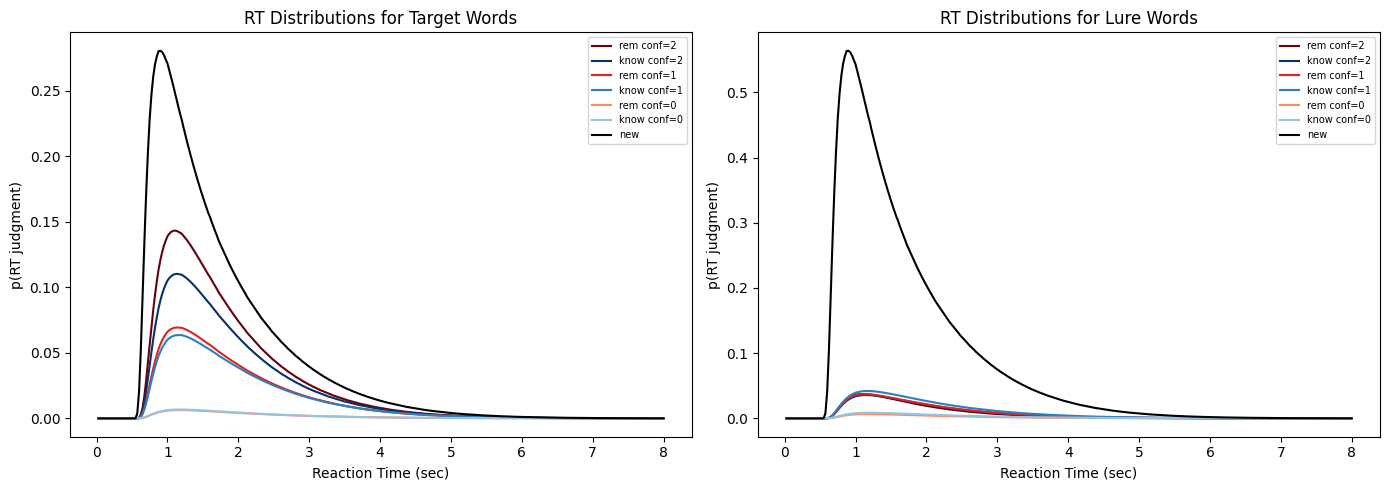

In [15]:
disp_model.plot_rt_distributions(params_est);

In [16]:
results = [
    disp_model.evaluate(params_est, method="qmpe"),
    disp_model.evaluate(params_est, method="qmle"),
    disp_model.evaluate(params_est, method="cml"),
]

display_comparison(results)


### Model Evaluation Comparison

| Metric | `QMPE` | `QMLE` | `CML` |
| :--- | ---: | ---: | ---: |
| **Trials ($N$)** | 7,735 | 7,735 | 7,735 |
| **Parameters ($k$)** | 12 | 12 | 12 |
| **Negative Log-Likelihood** | 493.28 | 578.36 | 18402.14 |
| **AIC** | **1010.57** | **1180.72** | **36828.28** |
| **BIC** | **1094.01** | **1264.16** | **36911.72** |


## SISP Constrained

use_chisq = True
params_est = SISPConstrainedDDM.Params(
    1.7802366345277048,
    1.0732968669582117,
    0.17804995041166943,
    0.5326415575619126,
    0.043589790458315514,
    0.9574460424899932,
    -0.690027580392909,
    -0.565893039286282,
    1.5546604244949078,
    0.12666843828878627,
    0.46706560655302104,
)

use_chisq = False
params_est = SISPConstrainedDDM.Params(
    c=np.float64(0.7801720218661342),
    mu_t=np.float64(0.0014979098410432545),
    mu_l=np.float64(0.00370279119459338),
    d=np.float64(0.3272418920383596),
    tc_bound=np.float64(0.199389361806869),
    r_bound_offset=np.float64(0.8539639746606412),
    z0_t=np.float64(0.14429099694980163),
    z0_l=np.float64(-0.3057233602542755),
    t_post=np.float64(0.35812500396288627),
    sigma_z0=np.float64(0.00872676895615948),
    t0=np.float64(0.4990057155454194),
)

In [21]:
sisp_model = SISPConstrainedDDM(
    config=caa_cfg,
    nr_threads=1,
)


method = "qmle"
params_est = SISPConstrainedDDM.Params(
    c=np.float64(0.7801720218661342),
    mu_t=np.float64(0.0014979098410432545),
    mu_l=np.float64(0.00370279119459338),
    d=np.float64(0.3272418920383596),
    tc_bound=np.float64(0.199389361806869),
    r_bound_offset=np.float64(0.8539639746606412),
    z0_t=np.float64(0.14429099694980163),
    z0_l=np.float64(-0.3057233602542755),
    t_post=np.float64(0.35812500396288627),
    sigma_z0=np.float64(0.00872676895615948),
    t0=np.float64(0.4990057155454194),
)

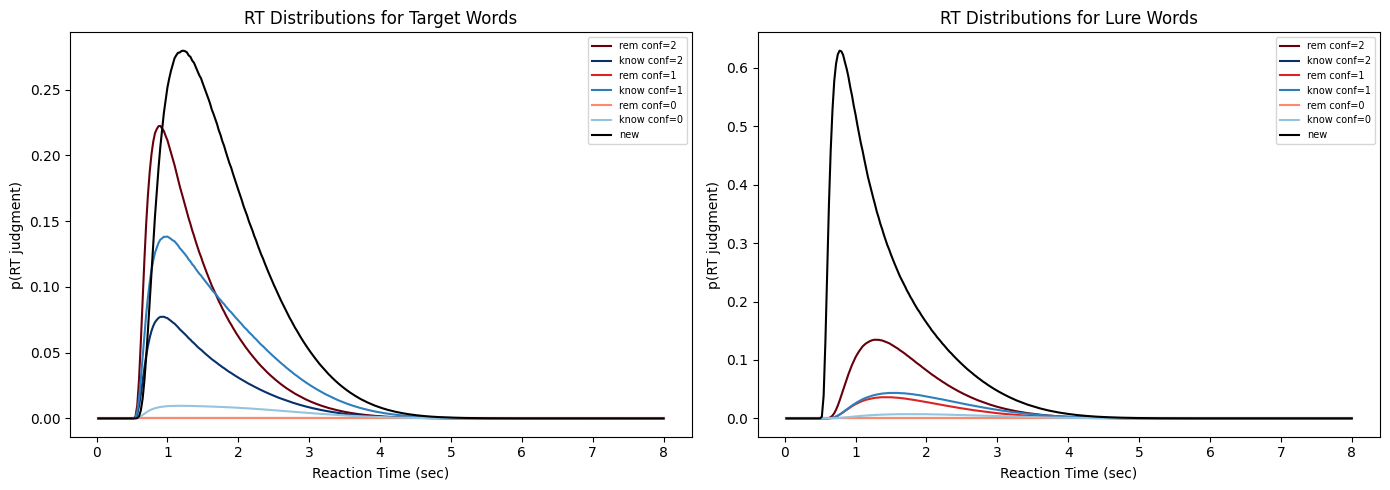

In [22]:
sisp_model.plot_rt_distributions(params_est);

In [23]:
results = [
    sisp_model.evaluate(params_est, method="qmpe"),
    sisp_model.evaluate(params_est, method="qmle"),
    sisp_model.evaluate(params_est, method="cml"),
]

display_comparison(results)


### Model Evaluation Comparison

| Metric | `QMPE` | `QMLE` | `CML` |
| :--- | ---: | ---: | ---: |
| **Trials ($N$)** | 7,735 | 7,735 | 7,735 |
| **Parameters ($k$)** | 11 | 11 | 11 |
| **Negative Log-Likelihood** | 11214.57 | 13633.73 | 20958.98 |
| **AIC** | **22451.13** | **27289.45** | **41939.95** |
| **BIC** | **22527.62** | **27365.94** | **42016.44** |


## DISP Staggered

Attempt use_qmpe=False, quantiles=10
params_est = DISPStaggeredDDM.Params(
    c=np.float64(0.9944747531085043),
    mu_r=np.float64(-0.09936966164007344),
    mu_f=np.float64(0.38569509914634637),
    d_r=np.float64(0.15453404227056255),
    d_f=np.float64(0.27144602850053545),
    tc_bound=np.float64(0.051699912298099504),
    r_bound=np.float64(0.006973033435801135),
    z0=np.float64(-0.12890907740414018),
    z0_new=np.float64(-0.2345484654891833),
    mu_r_new=np.float64(-0.3415451801281406),
    mu_f_new=np.float64(0.048392928941960456),
    t_post=np.float64(0.4824138548171153),
    t_delay_r=np.float64(0.23079148715627928),
    t0=np.float64(0.4985948017976732),
)

Attempt use_qmpe=True, quantiles=10
params_est = DISPStaggeredDDM.Params(
    c=np.float64(0.9999087451889589),
    mu_r=np.float64(0.0209897993808765),
    mu_f=np.float64(0.25768513423203177),
    d_r=np.float64(0.10189759738873257),
    d_f=np.float64(0.2982363721436817),
    tc_bound=np.float64(0.05450784071734566),
    r_bound=np.float64(0.08531378954287742),
    z0=np.float64(-0.12645062488910433),
    z0_new=np.float64(-0.20492685871782645),
    mu_r_new=np.float64(-0.15882429001981405),
    mu_f_new=np.float64(-0.11477742984885031),
    t_post=np.float64(0.48908906124509366),
    t_delay_r=np.float64(0.35000000357540006),
    t0=np.float64(0.4953236048050806),
)

Attempt use_qmpe=True, quantiles=5
params_est = DISPStaggeredDDM.Params(
    c=np.float64(0.9140167641103958),
    mu_r=np.float64(0.05927165205476144),
    mu_f=np.float64(0.19276971643042973),
    d_r=np.float64(0.0832728244656853),
    d_f=np.float64(0.27511269712947417),
    tc_bound=np.float64(0.1241894381706026),
    r_bound=np.float64(0.16584905374482012),
    z0=np.float64(-0.09269359029837772),
    z0_new=np.float64(-0.17857828698808734),
    mu_r_new=np.float64(-0.11589677539253383),
    mu_f_new=np.float64(-0.14670322526415291),
    t_post=np.float64(0.41545867811398923),
    t_delay_r=np.float64(0.15034956827930415),
    t0=np.float64(0.5329226816164254),
)

In [25]:
disp_staggered_model = DISPStaggeredDDM(
    config=caa_cfg,
    nr_threads=1,
)

method="qmle"
params_est = DISPStaggeredDDM.Params(
    c=np.float64(0.9944747531085043),
    mu_r=np.float64(-0.09936966164007344),
    mu_f=np.float64(0.38569509914634637),
    d_r=np.float64(0.15453404227056255),
    d_f=np.float64(0.27144602850053545),
    tc_bound=np.float64(0.051699912298099504),
    r_bound=np.float64(0.006973033435801135),
    z0=np.float64(-0.12890907740414018),
    z0_new=np.float64(-0.2345484654891833),
    mu_r_new=np.float64(-0.3415451801281406),
    mu_f_new=np.float64(0.048392928941960456),
    t_post=np.float64(0.4824138548171153),
    t_delay_r=np.float64(0.23079148715627928),
    t0=np.float64(0.4985948017976732),
)

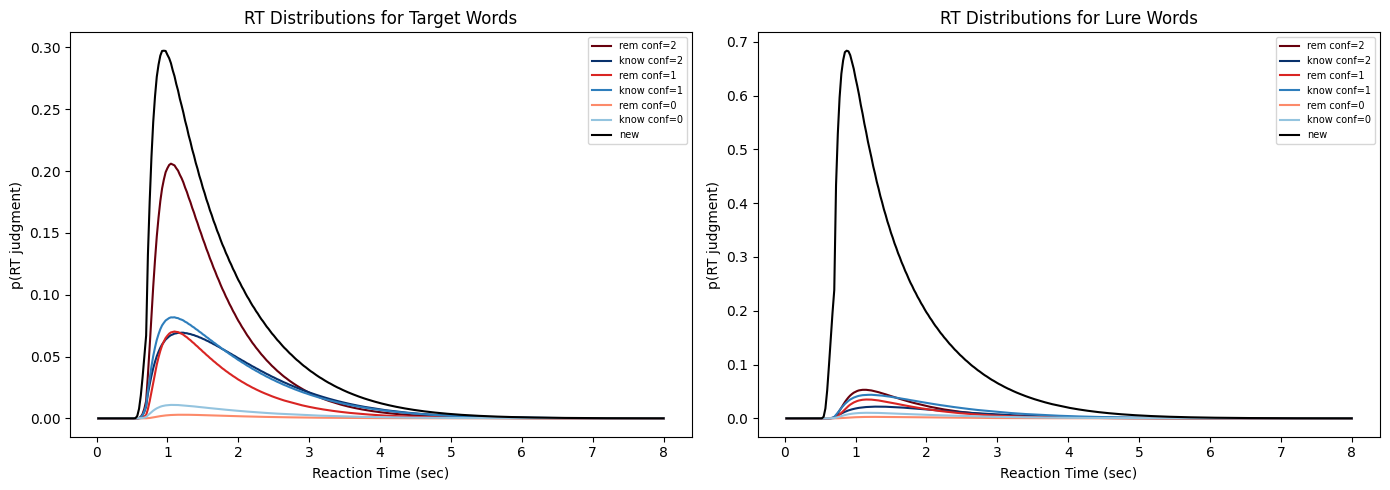

In [26]:
disp_staggered_model.plot_rt_distributions(params_est);

In [30]:
results = [
    disp_staggered_model.evaluate(params_est, method="qmpe"),
    disp_staggered_model.evaluate(params_est, method="qmle"),
    disp_staggered_model.evaluate(params_est, method="cml"),
]

display_comparison(results)


### Model Evaluation Comparison

| Metric | `QMPE` | `QMLE` | `CML` |
| :--- | ---: | ---: | ---: |
| **Trials ($N$)** | 7,735 | 7,735 | 7,735 |
| **Parameters ($k$)** | 14 | 14 | 14 |
| **Negative Log-Likelihood** | 496.29 | 489.61 | 18338.73 |
| **AIC** | **1020.57** | **1007.22** | **36705.46** |
| **BIC** | **1117.92** | **1104.57** | **36802.81** |


## Actual RT

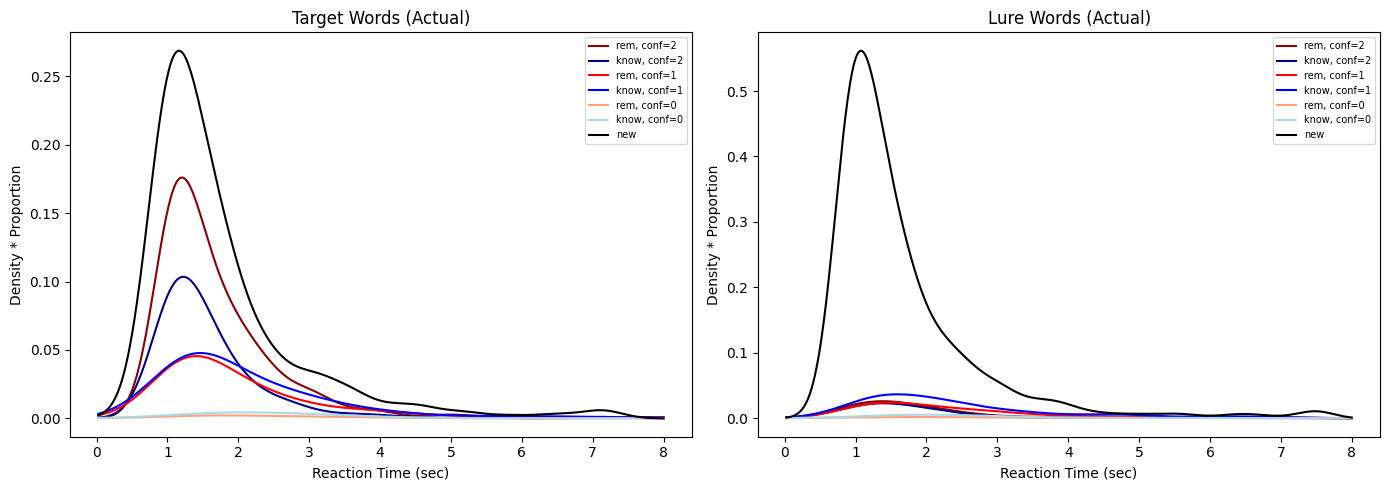

In [33]:
# Calculate total N for Targets and Lures to normalize the densities
N_target = len(data.rem_hit.rt) + len(data.know_hit.rt) + len(data.miss.rt)
N_lure = len(data.rem_fa.rt) + len(data.know_fa.rt) + len(data.CR.rt)

# Create a time axis for the KDE matching your model's maximum time
t_eval = np.linspace(CAA_CFG.delta_t, CAA_CFG.max_t, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
confidence_labels = ["conf=2", "conf=1", "conf=0"]

# We map the loop index to the actual confidence ratings in the data (2, 1, 0)
conf_vals = [2, 1, 0] 

colors_rem = ["darkred", "red", "lightsalmon"]
colors_know = ["darkblue", "blue", "lightblue"]

def plot_empirical_kde(ax, rt_data, total_N, color, label):
    """Generates a KDE for the RTs and scales it by its proportion of total trials."""
    if len(rt_data) > 1: # KDE requires at least a few data points
        try:
            kde = stats.gaussian_kde(rt_data)
            # Scale the density curve by the relative frequency of this response
            scaled_density = kde(t_eval) * (len(rt_data) / total_N)
            ax.plot(t_eval, scaled_density, color=color, label=label)
        except np.linalg.LinAlgError:
            pass # Skips plotting if there is zero variance in the small bin

# --- Target Words (Empirical) ---
for i, conf_val in enumerate(conf_vals):
    # Remember Hits
    rt_subset_rem = data.rem_hit.rt[data.rem_hit.conf == conf_val]
    plot_empirical_kde(axes[0], rt_subset_rem, N_target, colors_rem[i], f"rem, {confidence_labels[i]}")
    
    # Know Hits
    rt_subset_know = data.know_hit.rt[data.know_hit.conf == conf_val]
    plot_empirical_kde(axes[0], rt_subset_know, N_target, colors_know[i], f"know, {confidence_labels[i]}")

# Misses (Actual "New" responses to Targets)
plot_empirical_kde(axes[0], data.miss.rt, N_target, "black", "new")

axes[0].set_title("Target Words (Actual)")
axes[0].set_xlabel("Reaction Time (sec)")
axes[0].set_ylabel("Density * Proportion")
axes[0].legend(fontsize=7)

# --- Lure Words (Empirical) ---
for i, conf_val in enumerate(conf_vals):
    # Remember False Alarms
    rt_subset_rem = data.rem_fa.rt[data.rem_fa.conf == conf_val]
    plot_empirical_kde(axes[1], rt_subset_rem, N_lure, colors_rem[i], f"rem, {confidence_labels[i]}")
    
    # Know False Alarms
    rt_subset_know = data.know_fa.rt[data.know_fa.conf == conf_val]
    plot_empirical_kde(axes[1], rt_subset_know, N_lure, colors_know[i], f"know, {confidence_labels[i]}")

# Correct Rejections (Actual "New" responses to Lures)
plot_empirical_kde(axes[1], data.CR.rt, N_lure, "black", "new")

axes[1].set_title("Lure Words (Actual)")
axes[1].set_xlabel("Reaction Time (sec)")
axes[1].set_ylabel("Density * Proportion")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()